In [30]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

# print("Path to dataset files:", path)

In [31]:
import numpy as np
import pandas as pd
import sklearn

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, average_precision_score, accuracy_score
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import RobustScaler, LabelEncoder


from pylab import rcParams

In [32]:
df = pd.read_csv( "creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class == 1 é a fraude

As variáveis V1 a V28 são o resultado de uma transformação PCA (Análise de Componentes Principais).

In [33]:
df.shape

(284807, 31)

In [34]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [35]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

O dataframe já está limpo, precisamos somente trabalhar com ele

Vamos dar uma olhada na proporção de fraudes

In [36]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

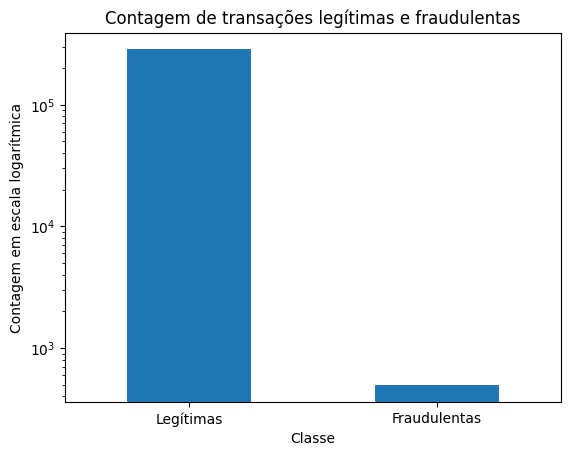

In [37]:
contagem = df['Class'].value_counts(sort=True)

contagem.plot(kind='bar', rot=0)

plt.title("Contagem de transações legítimas e fraudulentas")
plt.xlabel("Classe")
plt.ylabel("Contagem em escala logarítmica")
plt.yscale('log')  # Usar escala logarítmica para melhor visualização
plt.xticks(range(2), labels = ['Legítimas', 'Fraudulentas'])
plt.show()


Vamos separar em 2 tabelas as transações fradulentas e as legítimas, a fim de observar o que pode caracterizar uma transação fraudulenta para analise posterior

In [38]:
fraudes = df[df['Class'] == 1]
legitimas = df[df['Class'] == 0]

In [39]:
fraudes.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [40]:
fraudes['Amount'].value_counts()

Amount
1.00      113
0.00       27
99.99      27
0.76       17
0.77       10
         ... 
349.08      1
390.00      1
77.89       1
245.00      1
42.53       1
Name: count, Length: 259, dtype: int64

Ou seja, a maior parte das transações fraudulentas nessa database é de valores baixos

In [41]:
legitimas['Amount'].describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [42]:
legitimas['Amount'].value_counts()

Amount
1.00      13575
1.98       6044
0.89       4872
9.99       4746
15.00      3280
          ...  
787.95        1
405.09        1
381.05        1
337.54        1
95.63         1
Name: count, Length: 32701, dtype: int64

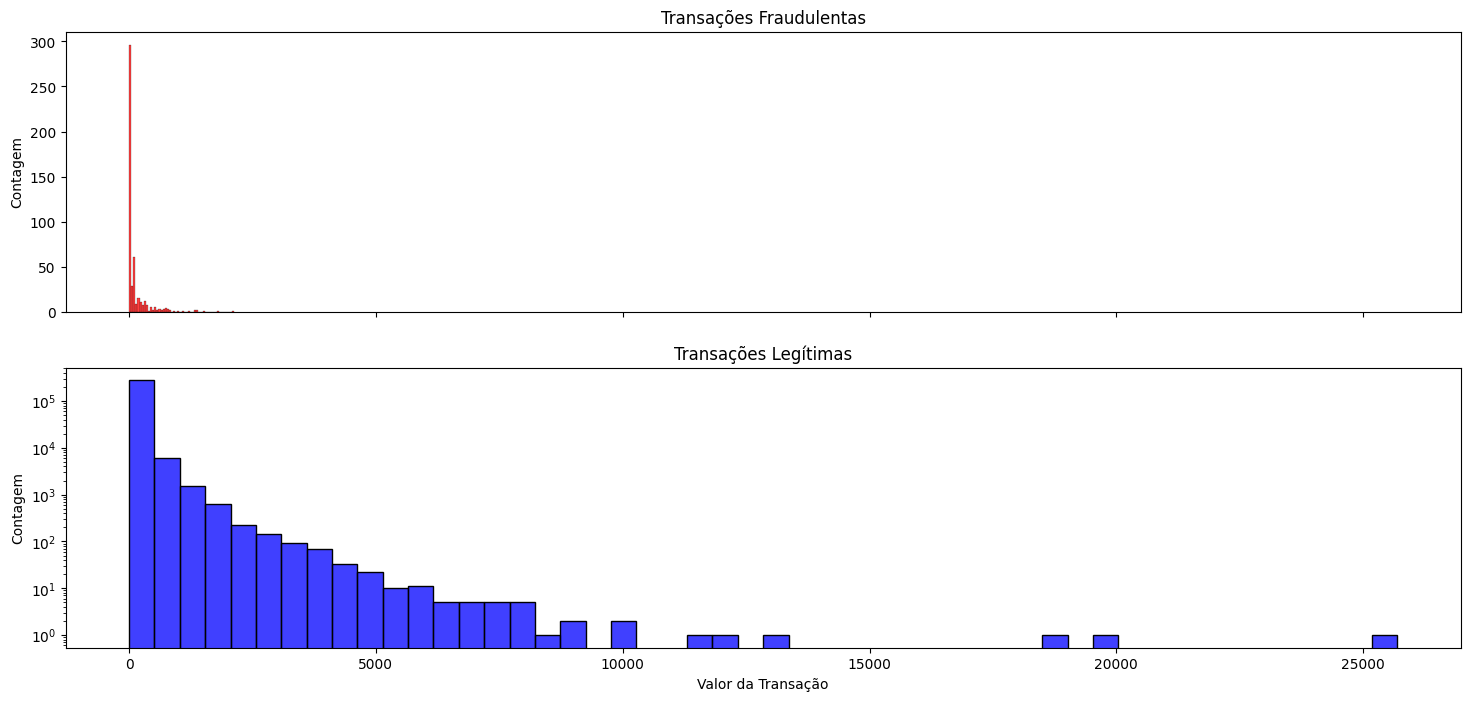

In [43]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.set_size_inches(18, 8)
sns.histplot(legitimas['Amount'], bins=50, ax=ax2, color='blue')
sns.histplot(fraudes['Amount'], bins=50, ax=ax1, color='red')
ax2.set_title('Transações Legítimas')
ax1.set_title('Transações Fraudulentas')
ax2.set_xlabel('Valor da Transação')
ax1.set_ylabel('Contagem')
ax2.set_ylabel('Contagem')
ax1.set_xlabel('Valor da Transação')
plt.yscale('log')  # Usar escala logarítmica para melhor visualização
plt.show()

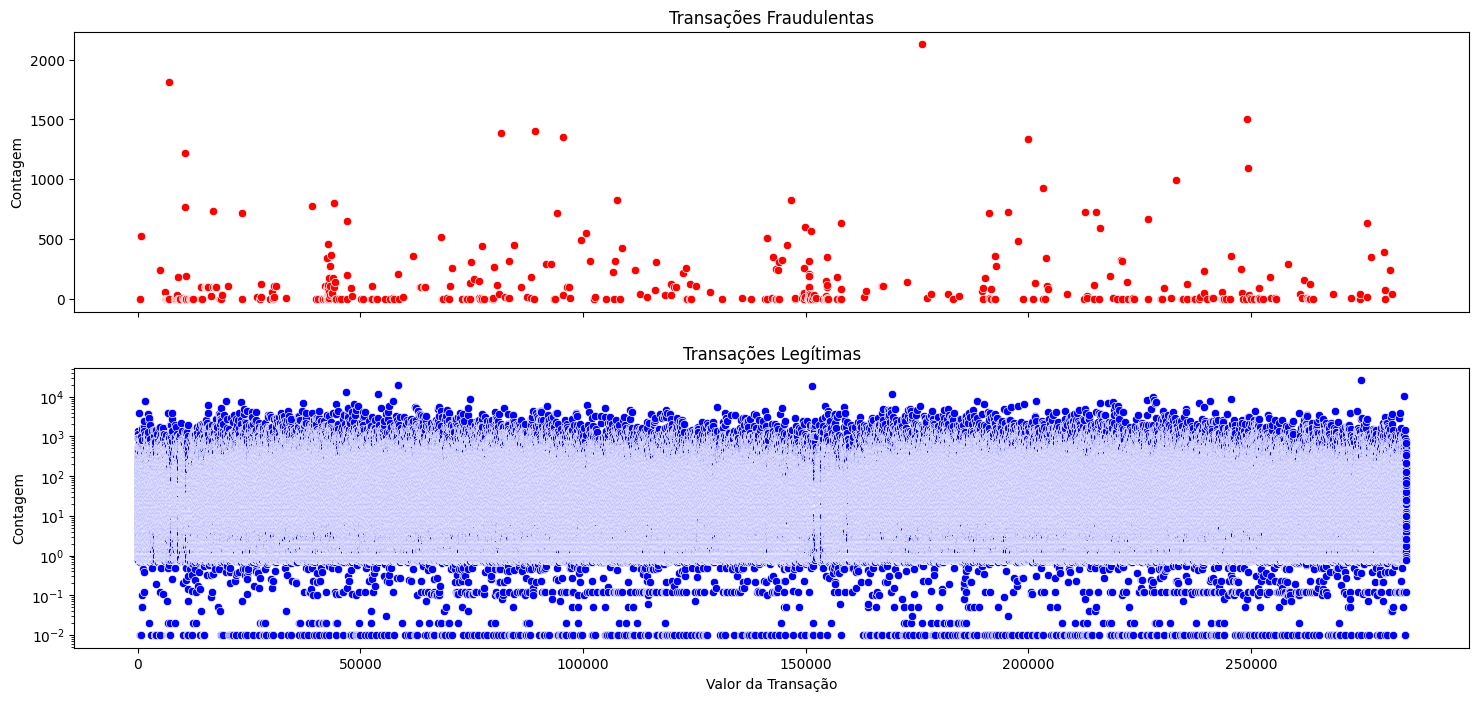

In [44]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.set_size_inches(18, 8)
sns.scatterplot(legitimas['Amount'], ax=ax2, color='blue')
sns.scatterplot(fraudes['Amount'], ax=ax1, color='red')
ax2.set_title('Transações Legítimas')
ax1.set_title('Transações Fraudulentas')
ax2.set_xlabel('Valor da Transação')
ax1.set_ylabel('Contagem')
ax2.set_ylabel('Contagem')
ax1.set_xlabel('Valor da Transação')
plt.yscale('log')  # Usar escala logarítmica para melhor visualização
plt.show()

/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


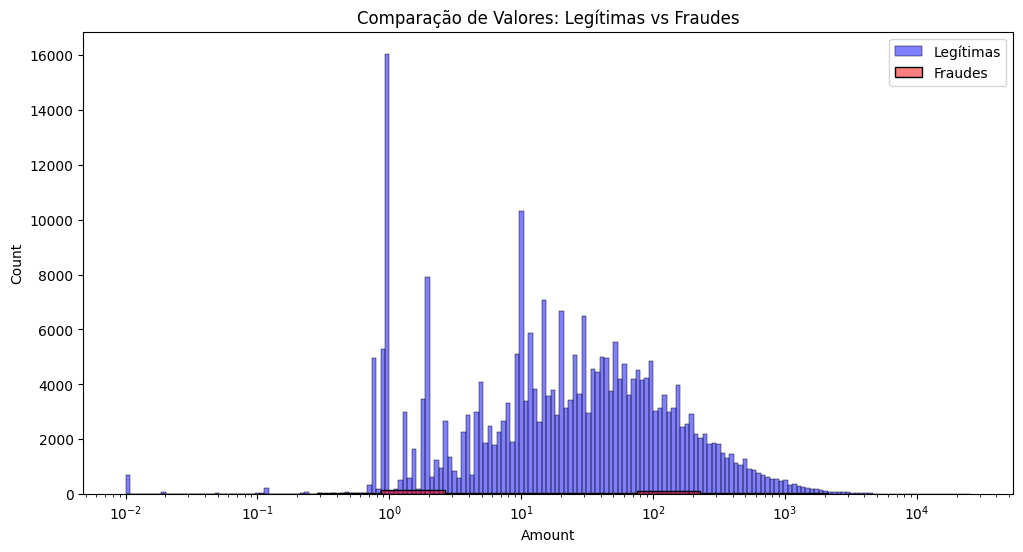

In [45]:
plt.figure(figsize=(12, 6))
sns.histplot(legitimas['Amount'], color='blue', label='Legítimas', kde=True, log_scale=True)
sns.histplot(fraudes['Amount'], color='red', label='Fraudes', kde=True, log_scale=True)
plt.title('Comparação de Valores: Legítimas vs Fraudes')
plt.legend()
plt.show()

/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


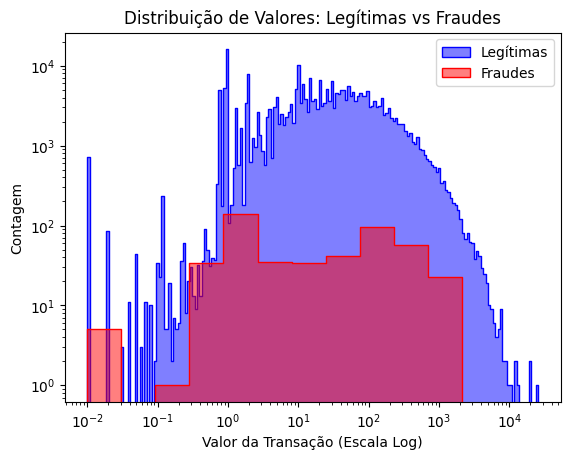

In [46]:
sns.histplot(data=legitimas, x='Amount', color='blue', label='Legítimas', kde=True, element='step', log_scale=True)
sns.histplot(data=fraudes, x='Amount', color='red', label='Fraudes', kde=True, element='step', log_scale=True)

plt.title('Distribuição de Valores: Legítimas vs Fraudes')
plt.xlabel('Valor da Transação (Escala Log)')
plt.ylabel('Contagem')
plt.legend()
plt.yscale('log')  # Usar escala logarítmica para melhor visualização
plt.show()

/tmp/ipykernel_2687/3611726135.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x='Class', y='Amount', palette={'Legitima': 'b', 'Fraude': 'r'})


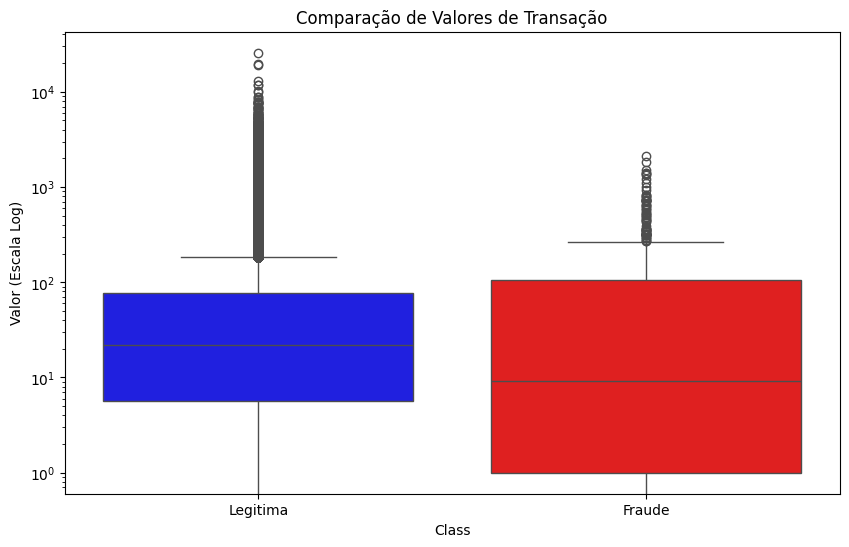

In [47]:
legitimas['Class'] = 'Legitima'
fraudes['Class'] = 'Fraude'
df_combined = pd.concat([legitimas, fraudes])


plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='Class', y='Amount', palette={'Legitima': 'b', 'Fraude': 'r'})

plt.yscale('log') # Useful if there are massive outliers
plt.title('Comparação de Valores de Transação')
plt.ylabel('Valor (Escala Log)')
plt.show()

é facil de observar que a maior parte das fraudes se concentram em uma área restrista, com alguns pontos fora

# Modelos

In [48]:
data1 = df.sample(frac=0.1, random_state=42) # Usar uma amostra menor para acelerar o processo de modelagem

In [49]:
contagem_fraudes = data1[data1['Class'] == 1]
contagem_valido = data1[data1['Class'] == 0]

outlier_fraction = len(contagem_fraudes)/float(len(contagem_valido))

print(outlier_fraction)

0.001617724635132759


devido a isso, a nossa melhor opção é usar uma classe balanceada se usar random forest

In [50]:
print("Fraudes: {}".format(len(contagem_fraudes)))
print("Valido: {}".format(len(contagem_valido)))

Fraudes: 46
Valido: 28435


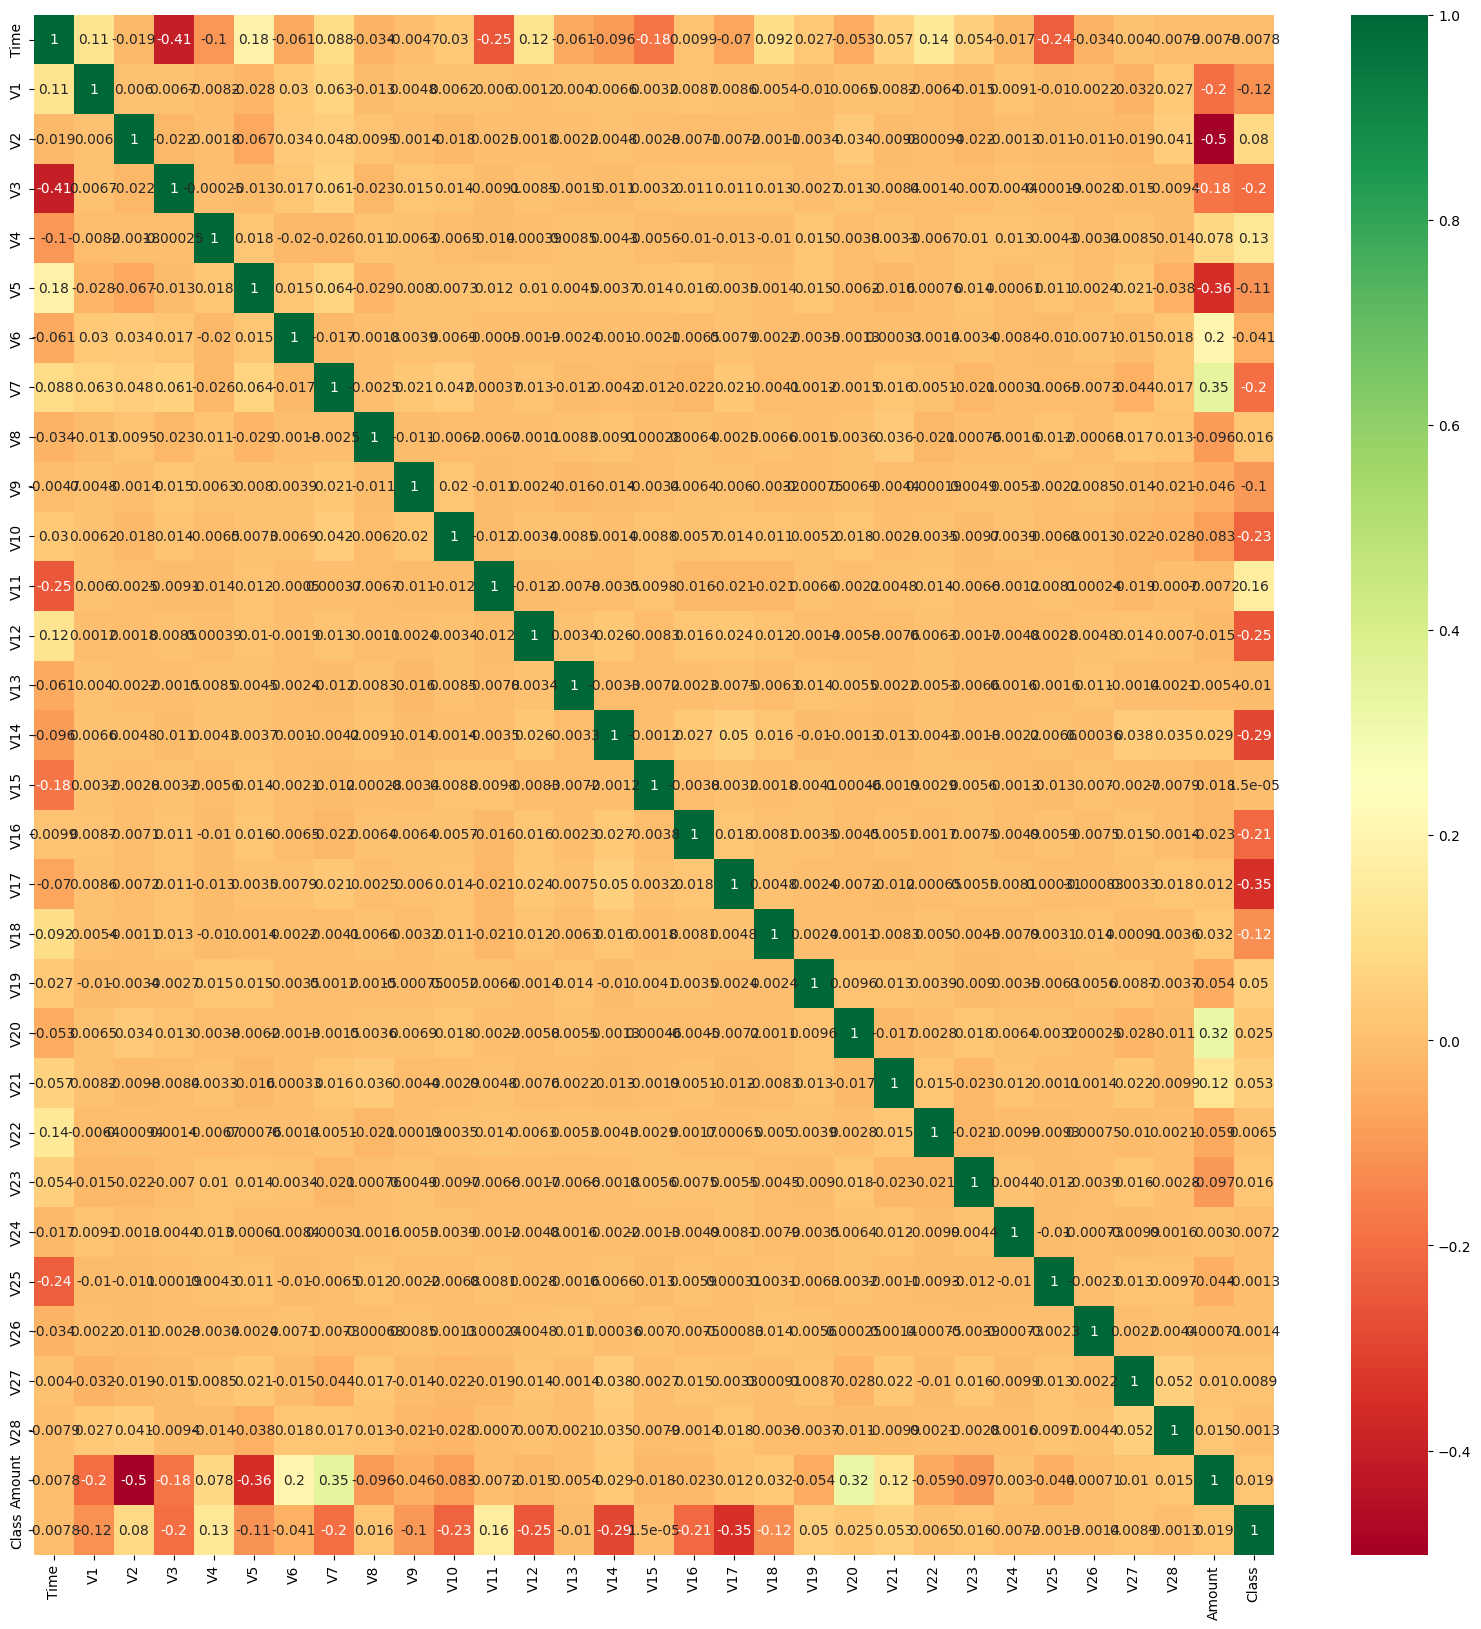

In [51]:
corrmat = data1.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))

g = sns.heatmap(data1[top_corr_features].corr(), annot=True, cmap="RdYlGn")

In [52]:
columns = data1.columns.tolist()
columns = [c for c in columns if c not in ["Class"]] #removendo a coluna de classe
target = "Class" #preciso armazenar a variável de classe em uma variável separada para treinar o modelo
state = np.random.RandomState(42)
X = data1[columns]
y = data1[target]
X_outliers = state.uniform(low=0, high=1, size=(X.shape[0], X.shape[1]))

print(X.shape)
print(y.shape)

(28481, 30)
(28481,)


In [53]:
classificadores = {
    "Isolation Forest": IsolationForest(n_estimators=100, max_samples=len(X),
                                        contamination=outlier_fraction, random_state=42, verbose=0), #verbose=0 para não mostrar mensagens de treinamento
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=100, n_jobs=-1,
    random_state=42, class_weight='balanced'
)
}

In [54]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Class']), df['Class'].values, test_size=0.2, random_state=42)

scaler = RobustScaler() #usando RobustScaler para lidar melhor com outliers
num_cols = X_train.select_dtypes(include=[np.number]).columns #selecionando apenas as colunas numéricas para escalonamento
scaler.fit(X_train[num_cols]) #ajustando o scaler apenas nos dados de treino

X_train[num_cols] = scaler.transform(X_train[num_cols]) #transformando os dados de treino
X_test[num_cols] = scaler.transform(X_test[num_cols]) #transformando os dados de teste usando o mesmo scaler ajustado nos dados de treino

In [55]:
n_outliers = len(contagem_fraudes)

results=[]

for i, (nome, classificador) in enumerate(classificadores.items()):
    #comparando os algoritmos/modelos
    if nome == "Random Forest":
        classificador.fit(X_train, y_train)
        scores_pred = classificador.predict_proba(X_test)[:, 1] #probabilidade de ser fraude
        y_pred = classificador.predict(X_test)
    else:
        classificador.fit(X_train)
        scores_pred = classificador.decision_function(X_test)
        y_pred = classificador.predict(X_test)
        y_pred[y_pred == 1] = 0
        y_pred[y_pred == -1] = 1
    n_errors = (y_pred != y_test).sum()
    
    print("{}: {}".format(nome, n_errors))
    print("Accuracy Score :")
    print(accuracy_score(y_test, y_pred))
    print("Classification Report :")
    if nome == "Random Forest":
        print(classification_report(y_test, (scores_pred>0.8).astype(int)))
    else:
        print(classification_report(y_test, y_pred))
        
    
    results.append({
        'model': nome,
        'roc_auc': roc_auc_score(y_test, scores_pred), #calculando a métrica ROC AUC para avaliar o desempenho do modelo
        'aucprc': average_precision_score(y_test, scores_pred) #calculando a métrica AUC-PRC para avaliar o desempenho do modelo em dados desbalanceados
    })


Isolation Forest: 120
Accuracy Score :
0.9978933323970366
Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.36      0.29      0.32        98

    accuracy                           1.00     56962
   macro avg       0.68      0.64      0.66     56962
weighted avg       1.00      1.00      1.00     56962

Random Forest: 63
Accuracy Score :
0.9988939995084443
Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.77      0.82        98

    accuracy                           1.00     56962
   macro avg       0.94      0.88      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [56]:
pd.DataFrame(results).sort_values(by='aucprc', ascending=False)

,model,roc_auc,aucprc
1,Random Forest,0.978685,0.747646
0,Isolation Forest,0.041120,0.000877


Ou seja, Random Forest é um método muito superior

In [57]:
import joblib

joblib.dump(classificadores["Random Forest"], 'random_forest_fraude.joblib')

['random_forest_fraude.joblib']